# Image-to-3D

> Everything to know about turning pictures into geometry: the two very different problems that share the name, the mid-2026 model landscape, why the metrics lie about the back of the object, and runnable code that fits on a 12 GB card.

- skip_showdoc: true
- skip_exec: true

## 1. What is Image-to-3D?

"Image-to-3D" is the Hugging Face pipeline tag for *any* model that takes pixels in and emits geometry out. That single tag hides **two problems that share almost nothing** - different inputs, different methods, different failure modes, and metrics that are not even comparable. Conflating them is the single most common confusion in this area, so this notebook is organised around the split:

| | **A. Multi-view reconstruction** | **B. Single-image 3D generation** |
|---|---|---|
| Input | many images (10s to 100s) of one scene/object | **one** image (or 2-4) |
| The 3D is | **measured** - the images constrain it | **hallucinated** - the back is invented |
| Problem class | inverse problem, well-posed given enough views | generative, fundamentally **ill-posed** |
| Methods | SfM + MVS (COLMAP), NeRF, 3D Gaussian Splatting, DUSt3R/VGGT | Zero-1-to-3, LRM/InstantMesh, TRELLIS, Hunyuan3D |
| Output | camera poses, depth maps, point cloud, radiance field, splats | a watertight textured mesh (an *asset*) |
| Ground truth exists? | **yes** - hold out a view and re-render it | **no** - nobody photographed the back |
| Metric | PSNR / SSIM / LPIPS on held-out novel views | Chamfer / F-score vs a GT mesh you usually do not have; human preference |
| Typical latency | minutes to hours | seconds |

**Input representation.** Both consume ordinary RGB images. Track A wants overlapping views with enough parallax (a pure rotation about the camera centre gives you *nothing*); track B wants the opposite - **one clean, centred, background-free object on a plain backdrop**, because that is the distribution it was trained on (Objaverse renders). Section 8 makes that concrete: feeding a cluttered photo to a single-image model is the #1 cause of a garbage mesh, and it is a preprocessing bug, not a model bug.

**Output representations.** Point cloud, depth/point map, implicit field (SDF / occupancy / NeRF), triplane, 3D Gaussians, and explicit mesh (+ UVs, +PBR maps). `14_Text_to_3D` owns the primer on what each representation is and the SDS-vs-feed-forward argument - read that first if the words "triplane" or "score distillation" are new; this notebook does not repeat it and instead goes deeper on the image-conditioned side.

**Neighbouring tasks** (separate models, usually chained):

| Task | What it does | Typical tool | Notebook |
|------|--------------|--------------|----------|
| Monocular depth estimation | one image -> per-pixel depth (the cheapest 2.5-D "3D") | Depth Anything V2, DepthPro | `00_Depth_Estimation` |
| Keypoint detection + matching | the correspondences SfM is literally built on | SuperPoint + LightGlue, SIFT | `17_Keypoint_Detection` |
| Mask generation | isolate the object before reconstruction | SAM 2, RMBG | `12_Mask_Generation` |
| Text-to-3D | same output, prompt instead of image | TRELLIS, Hunyuan3D | `14_Text_to_3D` |
| Novel-view synthesis | image + camera pose -> image (a 2-D task in service of 3-D) | Zero-1-to-3, Zero123++ | this notebook, section 10 |
| Image-to-video | an *orbit* video is a poor man's turntable | Stable Video Diffusion | `07_Image_to_Video` |

---

## 2. Real-World Use Cases

The two tracks are deployed by different industries with different constraints, which is why "which model is best" is unanswerable until you say which problem you have.

| Use case | Domain | Consumes / produces | Dominant constraint |
|----------|--------|---------------------|---------------------|
| Game / VFX asset drafting | Games, film (Meshy, Tripo, Rodin, Adobe Substance 3D) | concept art -> textured mesh with PBR maps | **Mesh hygiene**: quad topology, sane poly count, clean UVs, riggable. A pretty render that is 300k non-manifold triangles is useless |
| E-commerce 3D listings / AR try-on | Retail (Amazon "View in your room", IKEA, Shopify AR) | product photos -> glTF for the AR viewer | Metric scale and fidelity to the *actual* product - hallucinating the back of a sofa is a returns problem |
| Real-estate and property capture | Proptech (Matterport, Zillow 3D Home, Polycam) | phone video walkthrough -> navigable scene | Robust capture by untrained users; this is track **A** - the geometry must be measured, not invented |
| Cultural heritage / museum digitisation | Heritage, archaeology | photogrammetry rigs -> archival mesh | Accuracy and provenance. Generative infill is *forbidden* - you may not invent an artefact's missing half |
| Robotics scene understanding | Warehouse, AV | RGB(-D) stream -> point map, poses, occupancy | Real-time, on-board, metric scale; feed-forward pose-free models (VGGT/MASt3R) are what changed here |
| Medical / dental | Healthcare (intra-oral scanners, surgical planning) | calibrated views -> mesh | Sub-millimetre accuracy, regulatory validation. Generative models are not accepted |
| Avatar and UGC creation | Social, VTubing (Roblox, Snap) | one selfie/photo -> rigged avatar | Seconds of latency, must be rigged and animatable, runs at consumer scale |
| Product visualisation / configurators | Manufacturing, furniture | CAD or photos -> web-ready GLB | File size and draw calls; often mesh decimation matters more than generation |

**What the benchmark number hides.** Three things, all of them fatal in production.

First, **the benchmark scores a point cloud; the customer receives a mesh**. Chamfer distance does not know whether the mesh is watertight, manifold, self-intersecting, has 4 M degenerate triangles, has UVs, or has PBR maps separated from baked lighting. Every one of those decides whether an artist can use the asset, and *none* of them appear on a leaderboard. This is why studios still rebuild "AI 3D" output by hand.

Second, **the input distribution shift is brutal**. Open single-image models are trained overwhelmingly on Objaverse renders: one object, centred, uniform lighting, transparent background. A real photograph has a background, perspective distortion, cast shadows, cropping, and motion blur. Without a segmentation/matting step (section 8) the model will happily reconstruct the sofa behind the cat.

Third, **track A and track B fail differently**. Reconstruction fails *visibly* - textureless walls, specular surfaces, and low-parallax capture produce holes and floaters that you can see. Generation fails *invisibly* - it returns a confident, plausible, smooth object whose unseen half is a plausible-looking fiction. For heritage, medical and e-commerce that confident fiction is worse than a hole.

---

## 3. How Modern Image-to-3D Works

Two parallel histories. Track A is a geometry story; track B is a generative-modelling story. They are converging in 2026, but they got here from opposite directions.

### Track A - multi-view reconstruction (the measured one)

1. **Structure-from-Motion + MVS (2000s-, COLMAP).** Detect keypoints, match them across images, solve for cameras and a sparse point cloud by bundle adjustment, then densify with multi-view stereo and mesh with Poisson. Still the accuracy baseline, still the thing that produces the "ground truth" cameras everything else trains on. It runs on the matcher from `17_Keypoint_Detection` - SIFT classically, SuperPoint/LightGlue now - and it is slow (hours), brittle on textureless or specular scenes, and fails outright on low-parallax capture.
2. **NeRF (2020).** Fit an MLP mapping (x, y, z, view direction) to colour and density; render by volumetric ray marching; supervise on the input images. Photorealistic novel views, but the original took a day per scene and needed COLMAP poses first. Instant-NGP (2022) cut that to seconds with a hash grid.
3. **3D Gaussian Splatting (2023).** Represent the scene as millions of anisotropic 3-D Gaussians and rasterise them (no ray marching). Same or better fidelity than NeRF, **real-time rendering**, minutes to train. It won: 3DGS is the default scene representation in 2026, and the 3D Arena data shows humans prefer splat outputs over meshes even at equal geometry. It still wants COLMAP poses.
4. **Feed-forward, pose-free (2024-2026) - the actual revolution.** **DUSt3R** (CVPR 2024) took two uncalibrated images and regressed aligned *point maps* directly - no camera intrinsics, no bundle adjustment, no COLMAP. **MASt3R** added dense matching and localisation. **VGGT** (Visual Geometry Grounded Transformer, Meta + Oxford, **CVPR 2025 Best Paper**) generalised it: a single large transformer that ingests 1 to hundreds of views and regresses **camera intrinsics and extrinsics, depth maps, point maps and point tracks in one forward pass, in seconds**, with no geometric post-optimisation at all. This ends the "you must run COLMAP first" era for a large class of problems, and it is why robotics adopted it immediately. (VGGT is not in `transformers` as of mid-2026 - it still ships as the `vggt` package from its own repo - so it stays in prose here.)

### Track B - single-image generation (the hallucinated one)

1. **Per-shape optimisation / SDS (2022-2023).** DreamFusion-style score distillation, applied to an image via a reconstruction loss on the input view. Minutes to hours per object, and the Janus ("multi-face") problem. Detail in `14_Text_to_3D`; nobody ships this any more.
2. **Novel-view diffusion (2023) - the key idea.** **Zero-1-to-3** (Liu et al., ICCV 2023) asked a smarter question: instead of generating 3D, fine-tune a 2-D diffusion model to be **camera-conditioned** - "here is an object, now show me it from 40 degrees up and 90 degrees around". Then reconstruct from the generated views with any standard method. Suddenly Stable Diffusion's image prior does the hallucinating. The catch is **multi-view inconsistency**: each view is sampled independently, so the handle moves between frames and the reconstruction turns to mush. The fixes all *couple* the views during denoising: **Zero123++** (2023) tiles 6 fixed-pose views into one 960x640 image so a single denoising pass enforces consistency; **SyncDreamer** shares a 3-D volume across views; **MVDream** does joint multi-view attention.
3. **Large Reconstruction Models (2023-2024) - the feed-forward breakthrough.** **LRM** (Hong et al., 2023) skipped the optimisation entirely: a big transformer maps image tokens straight to a **triplane NeRF in about 5 seconds**. Trained on ~1M Objaverse objects, it showed 3D reconstruction is learnable as a regression problem. Its descendants are what people actually run: **InstantMesh** (multi-view diffusion + LRM + FlexiCubes -> mesh), **TripoSR** (Stability + Tripo, MIT, sub-second on an A100), and **Stable Fast 3D** (SF3D, 2024: mesh **plus UVs, material params and delighting** in ~0.5 s - the first to take asset hygiene seriously).
4. **Native 3D latent generation (2024-2026) - where the field is now.** Instead of diffusing *images* and lifting them, diffuse in a **learned 3-D latent space** and decode geometry directly. **TRELLIS** (Microsoft, Dec 2024) introduced *structured latents* (SLAT): a sparse voxel scaffold with local latent features, decodable to Gaussians, radiance fields **or** meshes from one latent. **TRELLIS.2** (4B, MIT, late 2025) replaced the iso-surface field with a "field-free" sparse **O-Voxel** structure plus a flow-matching transformer, handling open surfaces, sharp edges and transparency, with PBR. **Hunyuan3D 2.x** (Tencent) made the **two-stage shape-then-texture split** the production standard: a shape DiT generates untextured geometry, then a separate multi-view texture/PBR model paints it (2.1 was the first fully open release with production PBR; 3.x pushed geometry to 1536^3 but the top tiers are API-only). Also here: **TripoSG** (rectified-flow VAE, MIT) and **Direct3D-S2** (sparse SDF at high resolution).

### Trade-off cheat sheet

| Approach | Input | Time / asset | Output | Weakness |
|----------|-------|--------------|--------|----------|
| COLMAP (SfM+MVS) | 50-300 photos | hours | metric mesh + poses | textureless/specular scenes; needs parallax |
| 3D Gaussian Splatting | 30-200 photos + poses | minutes | splats (real-time render) | not a mesh; editing/relighting is awkward |
| VGGT / MASt3R | 1-hundreds, **no poses** | seconds | poses + depth + point maps | not a finished asset; needs meshing |
| SDS optimisation | 1 image | 10-60 min | NeRF/mesh | slow, Janus, saturated colours |
| Novel-view diffusion + recon | 1 image | 30 s - 2 min | mesh via lifted views | view inconsistency -> blurry geometry |
| LRM family (TripoSR, SF3D) | 1 image | 0.5-5 s | triplane NeRF -> mesh | blurry back side, low-res texture |
| Native 3D latents (TRELLIS, Hunyuan3D) | 1 image | 10 s - 3 min | mesh + PBR | 4B params, wants >= 16 GB VRAM |

**Who leads.** For measured geometry: 3DGS for rendering, VGGT for pose-free/fast, COLMAP still for accuracy. For generated assets: TRELLIS.2 and Hunyuan3D 2.1/3.x lead on open weights, and closed products (Meshy, Tripo, Rodin) still lead on the last mile - **texture and PBR quality, UV layout and topology**, which is exactly the part no benchmark scores.

---

## 4. Evaluation Metrics

Split the metrics exactly the way the problems split. Using track A's metrics on track B (or vice versa) is how papers make themselves look good.

### A. Multi-view reconstruction - ground truth exists, so measure it

Hold out views, re-render them, compare pixels.

$$PSNR = 10 \cdot \log_{10}\left(\frac{MAX_I^2}{MSE}\right), \qquad MSE = \frac{1}{N}\sum_i (\hat{x}_i - x_i)^2$$

plus **SSIM** (structural similarity, a windowed luminance/contrast/structure product) and **LPIPS** (distance between deep features - the one that best tracks human judgement). On DTU / Tanks-and-Temples with laser-scanned ground truth you can additionally report geometric **accuracy** (predicted-to-GT distance) and **completeness** (GT-to-predicted). This is honest: the images constrain the answer, and a held-out view is a real test.

### B. Single-image generation - no ground truth, so be suspicious

**Chamfer Distance** between predicted point set P and GT point set Q (lower is better; report the units and the normalisation, or the number is meaningless):

$$CD(P, Q) = \frac{1}{|P|}\sum_{p \in P}\min_{q \in Q}\lVert p - q\rVert_2^2 + \frac{1}{|Q|}\sum_{q \in Q}\min_{p \in P}\lVert q - p\rVert_2^2$$

**F-score at threshold tau** - the metric to prefer, because CD is dominated by outliers while F-score is a clean precision/recall trade-off:

$$P_\tau = \frac{1}{|P|}\left|\{p : \min_q \lVert p-q\rVert < \tau\}\right|, \quad R_\tau = \frac{1}{|Q|}\left|\{q : \min_p \lVert q-p\rVert < \tau\}\right|, \quad F_\tau = \frac{2 P_\tau R_\tau}{P_\tau + R_\tau}$$

**Normal consistency** - mean absolute cosine between the normal at each point and the normal of its nearest neighbour in the other set. Catches the case where the points are in the right place but the *surface* is noisy or facetted.

**CLIP similarity / CLIP-score** - cosine between the CLIP embedding of the input image and of renders of the generated object. Cheap, needs no GT mesh, and is what you use when (as usual) you have no GT mesh. It measures semantic agreement, not geometry: a well-textured blob can score well.

### The honest caveats (read these before quoting any number)

- **You cannot score the back of the object.** In the single-image case there is no ground truth for the unseen half unless you evaluate on a synthetic set with GT meshes (Google Scanned Objects, OmniObject3D). Papers that report CD on GSO are doing the right thing; papers that report CD "on our internal set" are not.
- **CD and F-score are dominated by the visible side.** The front of the object is measured; the back is invented; both are averaged into one number, and the front usually accounts for most of the surface area a metric samples. So these metrics **systematically overstate quality** - a model that nails the front and produces a smooth featureless back scores well.
- **Alignment and scale silently decide the winner.** CD requires the two shapes to be aligned and scaled the same way (ICP or a canonical normalisation). A different alignment convention moves CD by more than the gap between models.
- **The properties users actually care about are unmeasured**: watertight, 2-manifold, non-self-intersecting, poly count, quad vs triangle topology, clean UV layout, PBR maps separated from baked lighting, riggable. Nothing on any leaderboard scores these.
- Because of all this, the field's most credible ranking is **human preference**: [3D Arena](https://huggingface.co/spaces/dylanebert/3d-arena) (ELO from 100k+ pairwise votes). Its own analysis found that presentation confounds preference - splat renders beat mesh renders by ~17 ELO, and textured beats untextured by ~144 ELO, regardless of geometry.

**Speed metrics.** Seconds per asset (single-image generation), minutes per scene (reconstruction), and peak VRAM. For track A also report whether pose estimation is included in the timing - "3DGS trains in 5 minutes" often quietly excludes the 40-minute COLMAP run.

---

In [ ]:
# Toy metrics on fabricated point clouds - no model needed.
# Chamfer distance, F-score@tau and normal consistency, in plain numpy.
import numpy as np

rng = np.random.default_rng(0)

def sphere_points(n=800, r=1.0, jitter=0.0, rng=rng):
    "n points on a sphere of radius r, optionally jittered along the surface normal."
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    normals = v.copy()                      # for a sphere the normal IS the direction
    pts = v * (r + jitter * rng.normal(size=(n, 1)))
    return pts.astype(np.float32), normals.astype(np.float32)

def nn(a, b):
    "For each row of a, the squared distance to and index of its nearest row in b."
    d2 = ((a[:, None, :] - b[None, :, :]) ** 2).sum(-1)   # O(|a|*|b|) - fine at this size
    idx = d2.argmin(1)
    return d2[np.arange(len(a)), idx], idx

def chamfer(p, q):
    "Symmetric Chamfer distance (mean of squared NN distances, both directions)."
    dp, _ = nn(p, q)
    dq, _ = nn(q, p)
    return float(dp.mean() + dq.mean())

def fscore(p, q, tau=0.05):
    "Precision/recall of points within tau of the other cloud, and their harmonic mean."
    dp, _ = nn(p, q)
    dq, _ = nn(q, p)
    precision = float((np.sqrt(dp) < tau).mean())
    recall = float((np.sqrt(dq) < tau).mean())
    f = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return f, precision, recall

def normal_consistency(p, np_, q, nq):
    "Mean |cos| between each point's normal and its nearest neighbour's normal."
    _, ip = nn(p, q)
    _, iq = nn(q, p)
    a = np.abs((np_ * nq[ip]).sum(-1)).mean()
    b = np.abs((nq * np_[iq]).sum(-1)).mean()
    return float((a + b) / 2)

gt, gt_n = sphere_points(600)                        # "ground truth" mesh, sampled

rows = []
for noise in [0.30, 0.20, 0.10, 0.05, 0.02, 0.00]:  # a prediction that gets progressively better
    pred, pred_n = sphere_points(600, jitter=noise)
    cd = chamfer(pred, gt)
    f, prec, rec = fscore(pred, gt, tau=0.05)
    ncons = normal_consistency(pred, pred_n, gt, gt_n)
    rows.append((noise, cd, f, ncons))
    print(f"noise={noise:.2f}  CD={cd:.5f}  F-score@0.05={f:.3f} (P={prec:.2f} R={rec:.2f})  normal-cons={ncons:.3f}")

noise=0.30  CD=0.11753  F-score@0.05=0.030 (P=0.03 R=0.04)  normal-cons=0.994
noise=0.20  CD=0.06861  F-score@0.05=0.038 (P=0.04 R=0.04)  normal-cons=0.995
noise=0.10  CD=0.02908  F-score@0.05=0.082 (P=0.08 R=0.08)  normal-cons=0.996
noise=0.05  CD=0.01791  F-score@0.05=0.144 (P=0.14 R=0.15)  normal-cons=0.997
noise=0.02  CD=0.01478  F-score@0.05=0.254 (P=0.25 R=0.26)  normal-cons=0.996
noise=0.00  CD=0.01419  F-score@0.05=0.314 (P=0.31 R=0.32)  normal-cons=0.996


In [ ]:
# Two lessons in one chart: the metrics move the right way as the prediction improves,
# and F-score saturates once the error drops below tau (so a tau you did not choose
# carefully can hide a real quality difference).
from pyecharts import options as opts
from pyecharts.charts import Line

noises = [f"{r[0]:.2f}" for r in rows]
line = (
    Line()
    .add_xaxis(noises)
    .add_yaxis("Chamfer (x100, lower=better)", [round(r[1] * 100, 3) for r in rows], is_smooth=True)
    .add_yaxis("F-score@0.05 (higher=better)", [round(r[2], 3) for r in rows], is_smooth=True)
    .add_yaxis("Normal consistency", [round(r[3], 3) for r in rows], is_smooth=True)
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="Toy 3D metrics vs surface noise",
            subtitle="600-point spheres; F-score saturates once noise << tau",
        ),
        xaxis_opts=opts.AxisOpts(name="surface noise (radius units)"),
        yaxis_opts=opts.AxisOpts(name="score"),
        tooltip_opts=opts.TooltipOpts(trigger="axis"),
    )
)
line.render_notebook()

## 5. Datasets

| Dataset | Contents | Size | Scope | License | Typical use |
|---------|----------|------|-------|---------|-------------|
| [Objaverse](https://huggingface.co/datasets/allenai/objaverse) | CC-licensed 3D objects from Sketchfab | 800k objects | general objects | ODC-By 1.0 (per-asset CC) | **the** training set for every open single-image model |
| [Objaverse-XL](https://huggingface.co/datasets/allenai/objaverse-xl) | Objaverse + GitHub + Thingiverse + Polycam | ~10.2M objects | general | mixed, per-source | training the big ones (TRELLIS, Hunyuan3D) |
| [Google Scanned Objects](https://huggingface.co/datasets/Roldbach/google_scanned_objects) | laser-scanned real household products with **GT meshes** | 1030 objects | household goods | CC-BY 4.0 | **the** eval set for single-image 3D (CD / F-score / normal consistency) |
| [OmniObject3D](https://omniobject3d.github.io/) | real-scanned objects, 190 categories, GT meshes + videos | 6k objects | everyday objects | CC-BY-NC 4.0 (non-commercial) | eval with real (not CAD) ground truth |
| [CO3Dv2](https://github.com/facebookresearch/co3d) | turntable videos of real objects + COLMAP poses | 19k videos, 50 categories | 50 MS-COCO categories | CC-BY-NC 4.0 | training/eval for pose-free reconstruction (DUSt3R, VGGT) |
| [ShapeNet](https://shapenet.org/) | CAD models, canonical categories | 51k (core) | 55 categories | research-only, **gated** (registration required) | legacy benchmark; still cited, avoid for new work |
| [DTU](https://roboimagedata.compute.dtu.dk/) | 80 tabletop scenes, 49-64 calibrated views + **structured-light GT** | 80 scenes | objects | research-only | multi-view stereo accuracy/completeness |
| [Tanks and Temples](https://www.tanksandtemples.org/) | real scenes, laser-scanned GT, held-out test server | 21 scenes | scenes/objects | CC-BY-NC-SA | MVS + NeRF/3DGS benchmark |
| [Mip-NeRF 360](https://jonbarron.info/mipnerf360/) | 9 unbounded 360-degree scenes | 9 scenes | indoor/outdoor | CC-BY | the standard novel-view-synthesis (PSNR/SSIM/LPIPS) benchmark |
| [ScanNet / ScanNet++](http://www.scan-net.org/) | RGB-D indoor scans with meshes + semantics | 1500+ / 460 scenes | indoor scenes | research, **gated** (terms) | indoor reconstruction, depth, semantics |
| [RealEstate10K](https://google.github.io/realestate10k/) | 10M YouTube frames with camera poses | ~80k clips | indoor/outdoor tours | non-commercial, links only | camera-conditioned generation, pose-free training |
| [iso3d](https://huggingface.co/datasets/dylanebert/iso3d) | 30 curated input images used by 3D Arena | 30 images | generic objects | open | standard *input* prompts for image-to-3D comparison |

**This notebook** does not train, so it needs no big download: it evaluates on a handful of stable sample images (a clean studio-lit object plus a deliberately cluttered photo) and scores with CLIP similarity, since no GT mesh is available. **If you want a real number**, run your model over Google Scanned Objects and report F-score@0.05 with a stated alignment procedure - that is the closest thing to an honest, reproducible single-image 3D benchmark. Gated: ShapeNet and ScanNet require registration; OmniObject3D and CO3D are non-commercial.

---

## 6. The Model Landscape (mid-2026)

### Track A - reconstruction / pose estimation (measured)

| Model | Params | License | Input | Architecture | Best for | Runs on 12 GB? |
|-------|--------|---------|-------|--------------|----------|----------------|
| COLMAP | - | BSD | 20-300 images | SfM + MVS (classical) | accuracy baseline, GT poses | yes (CPU-hours) |
| 3D Gaussian Splatting | per-scene | research (Inria) | images + poses | rasterised 3-D Gaussians | real-time novel views | yes |
| DUSt3R / MASt3R | ~0.6B | CC-BY-NC | 2+ images, **no poses** | ViT -> point maps | pairwise pose-free recon | yes |
| **VGGT** / VGGT-1B-Commercial | 1.2B | CC-BY-NC / commercial variant | 1 to hundreds, no poses | single feed-forward transformer | **CVPR 2025 Best Paper**; cameras+depth+point maps in seconds | yes, but needs the `vggt` vendor repo |
| Depth Anything V2 | 25M-1.3B | Apache 2.0 / CC-BY-NC (large) | 1 image | DPT / DINOv2 | cheap 2.5-D depth (see `00_Depth_Estimation`) | **yes, transformers-native** |

### Track B - single-image generation (hallucinated)

| Model | Params | License | Output | Architecture | Best for | Runs on 12 GB? |
|-------|--------|---------|--------|--------------|----------|----------------|
| **Shap-E (img2img)** | ~0.3B | MIT | implicit fn -> NeRF **or** mesh | CLIP-image-conditioned latent diffusion over MLP weights | the one *diffusers-native* image-to-3D pipeline; crude by 2026 standards | **yes - the runnable demo here** |
| **Zero123++ v1.2** | ~1B (SD-1.5 based) | CC-BY-NC (weights) | 6 consistent novel views (not a mesh) | tiled multi-view diffusion | the novel-view stage of a lifting pipeline | **yes (~5 GB) - runnable here** |
| Zero-1-to-3 / -XL | ~1B | MIT (code) | 1 novel view per call | camera-conditioned SD | the original idea; view-inconsistent | yes (diffusers *community* pipeline) |
| TripoSR | 0.5B | **MIT** | triplane NeRF -> mesh | LRM | fastest decent open mesh (< 1 s) | yes, but **vendor repo code** (`model.ckpt` + `config.yaml`) |
| InstantMesh | ~1B | Apache 2.0 | mesh | Zero123++ views -> LRM -> FlexiCubes | good open mesh quality | yes, vendor repo |
| Stable Fast 3D | 1.1B | Stability community (gated) | mesh + **UVs + material + delighting** | LRM + mesh/UV heads | ~0.5 s assets that an artist can open | yes, vendor repo |
| TRELLIS-image-large | 1.2B | MIT | Gaussians / RF / **mesh** from one latent | structured latents (SLAT) | best quality/size open mesh 2025 | yes (~16 GB recommended), vendor repo |
| **TRELLIS.2-4B** | 4B | MIT | mesh + PBR, sharp edges, transparency | O-Voxel + flow-matching DiT | current open quality leader | **no** - too big for 12 GB |
| Hunyuan3D 2.1 | 3.3B shape + paint | Tencent community (EU/UK/KR restricted) | mesh + **production PBR** | shape DiT + multi-view PBR painter | best open *textures*; first full open release (code+weights) | tight; 2mini fits, full does not |
| Hunyuan3D 3.x | undisclosed | API tiers | mesh + PBR, 1536^3 geometry | hierarchical 3D-DiT | quality ceiling | no (API) |
| TripoSG | 1.5B | MIT | mesh | rectified-flow VAE + DiT | strong open geometry | yes, but needs `triposg` vendor module |
| Direct3D-S2 | ~1B | MIT | high-res SDF -> mesh | sparse SDF diffusion | high-resolution geometry | yes, vendor repo |

**Leaderboards.** [3D Arena](https://huggingface.co/spaces/dylanebert/3d-arena) (human-preference ELO, the credible one) and the [3DGen Leaderboard](https://huggingface.co/spaces/3DTopia/3DGen-Leaderboard). For track A, the [Mip-NeRF 360](https://jonbarron.info/mipnerf360/) and [Tanks and Temples](https://www.tanksandtemples.org/leaderboard/) tables.

**Who wins what.** Quality: TRELLIS.2 (geometry + PBR, open) and Hunyuan3D 3.x / Meshy / Tripo / Rodin (closed). Speed: SF3D and TripoSR, sub-second. Licence-clean commercial use: TRELLIS/TRELLIS.2, TripoSR, TripoSG (all MIT). Tie this back to section 2: the game-asset use case needs the *mesh hygiene* that only SF3D/Hunyuan3D/TRELLIS.2 attempt; the AR-commerce use case needs measured geometry and should be on track A, not track B, whatever the demo video suggests.

**The transformers/diffusers reality check.** Almost none of the good generators are HF-library-native. `Shap-E` is (via `diffusers`), and Zero123++ ships a hub-hosted `custom_pipeline`. TRELLIS (`library_name: trellis`), TRELLIS.2 (`trellis2`), Hunyuan3D (`hunyuan3d-2`), TripoSR (raw `.ckpt`), SF3D and TripoSG (`triposg.*` modules in its `model_index.json`) all require **their own repository's code on your path**, and VGGT is still not merged into `transformers` (the PR is open). Per this repo's general-purpose-library rule, those stay in prose - clone their repos in a separate environment if you need them. **What that costs you is real: the runnable cells below are the 2023-generation models, and they look it.** Say so in any comparison you publish.

---

## 7. Setup

Package roles:

- `diffusers` + `transformers` + `torch` - Shap-E (`ShapEImg2ImgPipeline`), Zero123++ (custom pipeline), RMBG-1.4 background removal, Depth Anything V2, CLIP scoring
- `accelerate` - device placement / low-CPU-memory loading
- `trimesh` - mesh inspection and `.ply` -> `.glb` conversion (import is guarded; the notebook degrades gracefully without it)
- `pyecharts` - all charts, including the 3-D scatter of the point cloud
- `pillow` / `numpy` - image handling, contact sheets, point maths

No vendor 3D packages (`trellis`, `hunyuan3d-2`, `triposg`, `vggt`, `sf3d`) are imported anywhere below - see the reality check above.

Everything runs on an RTX 3060 (12 GB) or on CPU (slowly - Shap-E on CPU takes minutes). All downloads land in `DL_tasks/datasets/`, which is gitignored.

---

In [ ]:
# All models load through Hugging Face diffusers / transformers - no vendor 3D packages.
# %pip install -q torch transformers diffusers accelerate pillow numpy pandas pyecharts

# Optional: mesh inspection + glb export (guarded below), and kornia for the
# Zero-1-to-3 community pipeline mentioned in section 10.
# %pip install -q trimesh kornia

In [ ]:
import ctypes
import ctypes.util
import gc
import time
import urllib.request
from pathlib import Path

import torch
from dotenv import find_dotenv, load_dotenv

# Knowledge/.env sets HF_TOKEN - authenticated HF Hub requests get higher rate limits
load_dotenv(find_dotenv(usecwd=True))

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device != "cpu" else torch.float32
if device != "cpu":
    print(torch.cuda.get_device_name(0))
print("device:", device)

def vram(tag=""):
    "Report current GPU memory (allocated / reserved). No-op on CPU."
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"VRAM {tag:20s} {alloc:5.2f} GB allocated / {reserved:5.2f} GB reserved")

def free_memory():
    "Collect garbage, empty the CUDA cache, and return freed CPU RAM to the OS."
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    # glibc keeps freed CPU allocations in its arenas instead of returning them
    # to the OS, so RSS compounds across model sections (cpu-offloaded weights
    # live in system RAM). malloc_trim(0) hands the freed arenas back. See
    # dl-visualization-and-memory.instructions.md - not optional on a 12 GB box.
    try:
        ctypes.CDLL(ctypes.util.find_library("c") or "libc.so.6").malloc_trim(0)
    except Exception:
        pass

# All downloads go to DL_tasks/datasets/ (gitignored)
DATA_DIR = Path("../../datasets")
DATA_DIR.mkdir(exist_ok=True)
HF_CACHE = str(DATA_DIR / "hf_cache")
OUT_DIR = DATA_DIR / "image_to_3d"
OUT_DIR.mkdir(exist_ok=True)

NVIDIA GeForce RTX 3060
device: cuda:0


corgi      (256, 256)
cats       (640, 480)
cat_clean  (768, 768)


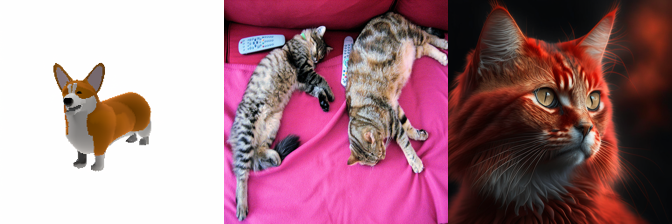

In [ ]:
from PIL import Image

# Two inputs, chosen to make the preprocessing point of section 8:
#   corgi  - a studio-lit object on a clean plain background = what the models were trained on
#   cats   - a real photograph: two cats on a cluttered sofa, off-centre, with a remote control
SAMPLES = {
    "corgi": ("https://hf.co/datasets/diffusers/docs-images/resolve/main/shap-e/corgi.png",
              DATA_DIR / "i23d_corgi.png"),
    "cats": ("http://images.cocodataset.org/val2017/000000039769.jpg",
             DATA_DIR / "i23d_cats.jpg"),
    "cat_clean": ("https://huggingface.co/datasets/hf-internal-testing/diffusers-images/resolve/main/kandinsky/cat.png",
                  DATA_DIR / "i23d_cat_clean.png"),
}

images = {}
for name, (url, path) in SAMPLES.items():
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    images[name] = Image.open(path).convert("RGB")
    print(f"{name:10s} {images[name].size}")

def contact_sheet(imgs, cols=3, cell=192, bg=(240, 240, 240)):
    "Tile PIL images into a single contact-sheet image (used for multi-view grids)."
    rows = (len(imgs) + cols - 1) // cols
    sheet = Image.new("RGB", (cols * cell, rows * cell), bg)
    for i, im in enumerate(imgs):
        sheet.paste(im.convert("RGB").resize((cell, cell)), ((i % cols) * cell, (i // cols) * cell))
    return sheet

contact_sheet(list(images.values()), cols=3, cell=224)

## 8. Preprocessing: isolate the object (the step everyone skips)

**This is not a footnote - it decides whether the rest works.** Every open single-image 3D model was trained on Objaverse *renders*: one object, centred, filling the frame, on a transparent or plain background, evenly lit. Hand it a photograph and it does what it was trained to do - reconstruct the whole scene into one blob, or lock onto the wrong object.

So the real pipeline is always: **segment / matte -> crop to the object -> pad to a square -> composite on white -> generate**. Production systems (Hunyuan3D, TRELLIS, InstantMesh) all ship a background remover in front of the model, usually SAM or a matting network.

Two transformers-native options:

- **`briaai/RMBG-1.4`** - a purpose-built salient-object matting model (IS-Net based). It loads through the `image-segmentation` pipeline with `trust_remote_code=True` and returns an RGBA image straight away. Tiny (~44M params), fast. **Licence: CC-BY-NC-4.0 - non-commercial** unless you buy a licence from BRIA (RMBG-2.0 is the newer, better sibling, same licence model). That matters if you ship this.
- **SAM / SAM 2** with a centre point or box prompt - see `12_Mask_Generation`. More general (you choose *which* object), no matting-quality alpha at the hair/fur boundary.

The alpha matte quality at the silhouette is what you are buying: single-image 3D models read the silhouette as a hard geometric constraint, so a fringe of sofa left around the cat becomes a fringe of geometry on the mesh.

---

In [ ]:
from transformers import pipeline as hf_pipeline

# RMBG-1.4 needs trust_remote_code (custom IS-Net architecture, not in transformers proper).
rmbg = hf_pipeline(
    "image-segmentation",
    model="briaai/RMBG-1.4",
    trust_remote_code=True,
    device=device,
    model_kwargs={"cache_dir": HF_CACHE},
)

def isolate(img, size=256, bg=(255, 255, 255)):
    "Matte out the background, crop to the object's bbox, pad square, composite on `bg`."
    cut = rmbg(img)                       # RGBA: alpha = the matte
    if cut.mode != "RGBA":
        cut = cut.convert("RGBA")
    box = cut.getchannel("A").getbbox()   # tight crop around non-transparent pixels
    if box is not None:
        cut = cut.crop(box)
    side = int(max(cut.size) * 1.15)      # 15% margin: the models expect the object to breathe
    square = Image.new("RGBA", (side, side), (*bg, 255))
    square.paste(cut, ((side - cut.width) // 2, (side - cut.height) // 2), cut)
    return square.convert("RGB").resize((size, size), Image.LANCZOS)

t0 = time.perf_counter()
clean = {name: isolate(img) for name, img in images.items()}
print(f"matted {len(clean)} images in {time.perf_counter() - t0:.1f}s")

del rmbg
free_memory()
vram("after RMBG")

# Top row: raw inputs. Bottom row: what the 3D model should actually be fed.
contact_sheet(
    [img.resize((256, 256)) for img in images.values()] + list(clean.values()),
    cols=3, cell=224,
)

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

MyConfig.py:   0%|          | 0.00/326 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/briaai/RMBG-1.4:
- MyConfig.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


MyPipe.py:   0%|          | 0.00/2.89k [00:00<?, ?B/s]

[transformers] Encountered exception while importing skimage: No module named 'skimage'


ImportError: This modeling file requires the following packages that were not found in your environment: skimage. Run `pip install skimage`

## 9. Track A in miniature: depth -> point cloud

The cheapest possible "measured" 3D is a single depth map back-projected through a pinhole camera. It costs 30 ms, it needs no poses, and it is a fair illustration of the geometric route - but it also shows exactly *why* the geometric route needs more than one image.

Two honest limitations, both visible in the output below:

1. **A monocular depth model gives you relative (often *inverse*) depth, not metric depth.** The unprojection is therefore correct only up to an unknown scale and shift, so the point cloud's proportions are wrong in a way you cannot fix from one image. Metric models (DepthPro, UniDepth) and multi-view methods (COLMAP, VGGT) are what fix this - see `00_Depth_Estimation`.
2. **You get a 2.5-D shell, not an object.** There is nothing behind the visible surface. That is the entire gap that track B's generative models exist to fill.

The intrinsics below are *invented* (a plausible focal length), which is the point: a real pipeline gets them from EXIF, calibration, or - since 2024 - regressed directly by DUSt3R/MASt3R/**VGGT**, which take unposed images and return cameras, depth and aligned point maps in one forward pass. VGGT is the model you would actually reach for here; it is not in `transformers` yet (`vggt` vendor repo only, CC-BY-NC weights with a separate `VGGT-1B-Commercial` checkpoint), so this cell uses the transformers-native depth model instead.

---

In [ ]:
import numpy as np

depth_pipe = hf_pipeline(
    "depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",  # 25M params, Apache 2.0
    device=device,
    model_kwargs={"cache_dir": HF_CACHE},
)

src = clean["corgi"]                       # the matted object from section 8
t0 = time.perf_counter()
pred = depth_pipe(src)
print(f"depth in {time.perf_counter() - t0:.2f}s")

d = pred["predicted_depth"].squeeze().float().cpu().numpy()   # relative INVERSE depth
d = np.array(Image.fromarray(d).resize(src.size, Image.BILINEAR))
d = (d - d.min()) / (d.max() - d.min() + 1e-8)

# Back-project with invented intrinsics. z ~ 1/(inverse_depth) is monotonic but NOT metric.
H, W = d.shape
f = 0.9 * W                                                    # made-up focal length
u, v = np.meshgrid(np.arange(W), np.arange(H))
z = 1.0 / (d * 2.0 + 0.35)                                     # avoid a divide-by-zero at the far plane
x = (u - W / 2) * z / f
y = -(v - H / 2) * z / f

rgb = np.asarray(src, dtype=np.uint8)
keep = d.reshape(-1) > 0.06                                    # drop the flat background plane
pts = np.stack([x, z, y], -1).reshape(-1, 3)[keep]             # ECharts 3D is y-up-ish; reorder axes
cols = rgb.reshape(-1, 3)[keep]

sel = np.random.default_rng(0).choice(len(pts), size=min(3000, len(pts)), replace=False)
pts, cols = pts[sel], cols[sel]                                # subsample: ECharts serialises to JSON
print("point cloud:", pts.shape)

del depth_pipe, pred
free_memory()
vram("after depth")

In [ ]:
from pyecharts import options as opts
from pyecharts.charts import Scatter3D

# Per-point colour via ECharts itemStyle. This is the legitimate use of a 3-D scatter:
# it is a point cloud, not a decorated bar chart.
data = [
    {"value": [round(float(p[0]), 4), round(float(p[1]), 4), round(float(p[2]), 4)],
     "itemStyle": {"color": f"#{c[0]:02x}{c[1]:02x}{c[2]:02x}"}}
    for p, c in zip(pts, cols)
]

scatter = (
    Scatter3D(init_opts=opts.InitOpts(width="820px", height="560px"))
    .add(
        "depth back-projection",
        data,
        symbol_size=3,
        xaxis3d_opts=opts.Axis3DOpts(name="x", type_="value"),
        yaxis3d_opts=opts.Axis3DOpts(name="z (depth)", type_="value"),
        zaxis3d_opts=opts.Axis3DOpts(name="y", type_="value"),
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="Single-image point cloud (Depth Anything V2)",
            subtitle="A 2.5-D shell: relative depth, invented intrinsics, nothing behind the surface",
        )
    )
)
scatter.render_notebook()

## 10. Novel-view diffusion: Zero123++

**The idea that unlocked single-image 3D.** Zero-1-to-3 (ICCV 2023) fine-tuned Stable Diffusion on Objaverse renders with the *relative camera transform* as an extra condition. The model no longer answers "what image matches this text" but "what does *this object* look like from 40 degrees up and 90 degrees around". You then lift the generated views to 3D with any reconstructor. The image prior does the hallucinating, and the geometry stays somebody else's problem.

Its flaw is **multi-view inconsistency**: each view is a separate sample from a distribution, so the corgi's ear is in a different place in each one and the reconstruction averages them into mush. **Zero123++** (`sudo-ai/zero123plus-v1.2`) fixes this the blunt way: it generates all **six views as one tiled 960x640 image** (elevations +20 and -10 degrees; azimuths 30, 90, 150, 210, 270, 330), so a single denoising pass with global self-attention sees every view at once and *has* to keep them consistent. It is the front half of InstantMesh and of many production pipelines.

It ships a hub-hosted `custom_pipeline`, so it is loadable through plain `diffusers` (~5 GB VRAM). **Note the output is images, not geometry** - lifting them to a mesh needs a reconstructor (InstantMesh's LRM), which is vendor code. Weights are **CC-BY-NC-4.0**.

The original Zero-1-to-3 is also reachable from `diffusers` as a *community* pipeline - `DiffusionPipeline.from_pretrained("kxic/zero123-165000", custom_pipeline="pipeline_zero1to3")`, which takes explicit `poses=[polar, azimuth, radius]` per view and needs `kornia` installed. Use it if you want to see the inconsistency for yourself; Zero123++ is what you would actually deploy.

---

In [ ]:
from diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler

mv = DiffusionPipeline.from_pretrained(
    "sudo-ai/zero123plus-v1.2",
    custom_pipeline="sudo-ai/zero123plus-pipeline",  # hosted alongside the weights
    torch_dtype=dtype,
    cache_dir=HF_CACHE,
)
mv.scheduler = EulerAncestralDiscreteScheduler.from_config(
    mv.scheduler.config, timestep_spacing="trailing"
)
mv = mv.to(device)

t0 = time.perf_counter()
grid = mv(clean["corgi"], num_inference_steps=28).images[0]   # 28 steps is enough for plain objects
print(f"6 views in {time.perf_counter() - t0:.1f}s -> {grid.size} (a 3x2 tile of 320x320 views)")

# Split the tile back into the six views and show them as a contact sheet.
def split_grid(g, rows=3, cols=2):
    w, h = g.width // cols, g.height // rows
    return [g.crop((c * w, r * h, (c + 1) * w, (r + 1) * h)) for r in range(rows) for c in range(cols)]

views = split_grid(grid)
del mv, grid
free_memory()
vram("after zero123++")

contact_sheet(views, cols=3, cell=200)

## 11. Shap-E img2img: one image in, a mesh out

The only **diffusers-native** image-to-3D pipeline. Shap-E (OpenAI, 2023) diffuses in the space of *implicit-function parameters*: the latent it samples IS the weight vector of a small MLP, which can be evaluated as a NeRF (render a turntable) or marching-cubed into a **textured mesh**. `openai/shap-e-img2img` conditions that on a CLIP **image** embedding instead of text.

**Set expectations honestly.** This is a 2023 model, ~0.3B params, and it shows: blobby geometry, muddy vertex colours, no PBR, no UVs, and it is conditioned only on a global CLIP embedding - so it captures the *category* of your input far better than the *instance*. TripoSR, TRELLIS.2 and Hunyuan3D are enormously better. Shap-E is here because it is the only one that runs from `pip install diffusers` with no vendor repo, it is fast (seconds), and it demonstrates the whole shape - image in, mesh out, exported to disk - end to end.

Two calls: `output_type` defaults to `"pil"` (a list of rendered turntable frames -> GIF) and `output_type="mesh"` gives a `MeshDecoderOutput` that `export_to_ply` writes to disk.

---

In [ ]:
from diffusers import ShapEImg2ImgPipeline
from diffusers.utils import export_to_gif
from IPython.display import Image as IPyImage

shap_e = ShapEImg2ImgPipeline.from_pretrained(
    "openai/shap-e-img2img",
    torch_dtype=dtype,
    variant="fp16" if device != "cpu" else None,
    cache_dir=HF_CACHE,
).to(device)

t0 = time.perf_counter()
frames = shap_e(
    clean["corgi"],          # the MATTED image from section 8, not the raw photo
    guidance_scale=3.0,
    num_inference_steps=64,
    frame_size=256,
).images[0]                  # a list of PIL frames orbiting the object
print(f"turntable ({len(frames)} frames) in {time.perf_counter() - t0:.1f}s")

gif_path = export_to_gif(frames, str(OUT_DIR / "corgi_turntable.gif"))
display(IPyImage(filename=gif_path))
contact_sheet(frames[::max(1, len(frames) // 6)][:6], cols=3, cell=160)

In [ ]:
from diffusers.utils import export_to_ply

# Same pipeline, mesh output. The mesh comes out of a marching-cubes pass over the
# implicit function, so vertex count is a function of the grid, not of the object.
t0 = time.perf_counter()
mesh = shap_e(
    clean["corgi"],
    guidance_scale=3.0,
    num_inference_steps=64,
    frame_size=256,
    output_type="mesh",
).images[0]
print(f"mesh in {time.perf_counter() - t0:.1f}s")

ply_path = export_to_ply(mesh, str(OUT_DIR / "corgi.ply"))
print("wrote", ply_path)

verts = mesh.verts.detach().cpu().numpy()
faces = mesh.faces.detach().cpu().numpy()
print(f"vertices={len(verts)}  faces={len(faces)}")

del shap_e
free_memory()
vram("after shap-e")

# Mesh hygiene: the properties a downstream artist actually cares about, none of which
# appear on any leaderboard. trimesh is optional - guard it.
def inspect_mesh(ply_file):
    "Report vertex/face counts, watertightness, manifoldness and volume; export a .glb."
    try:
        import trimesh
    except ImportError:
        print("trimesh not installed - skipping mesh inspection (pip install trimesh)")
        return None
    import numpy as np

    m = trimesh.load(str(ply_file), force="mesh")
    rot = trimesh.transformations.rotation_matrix(-np.pi / 2, [1, 0, 0])  # shap-e exports bottom-up
    m.apply_transform(rot)
    glb = str(Path(ply_file).with_suffix(".glb"))
    m.export(glb, file_type="glb")
    info = {
        "vertices": len(m.vertices),
        "faces": len(m.faces),
        "watertight": bool(m.is_watertight),
        "winding_consistent": bool(m.is_winding_consistent),
        "euler_number": int(m.euler_number),
        "volume": float(m.volume) if m.is_watertight else float("nan"),
        "has_uvs": m.visual.uv is not None if hasattr(m.visual, "uv") else False,
        "glb": glb,
    }
    for k, v in info.items():
        print(f"  {k:20s} {v}")
    return m

mesh_obj = inspect_mesh(ply_path)

In [ ]:
# The generated mesh as a point cloud, in ECharts. Watch the BACK of the object as you
# rotate it: that half was never observed, and no metric in section 4 can tell you
# whether it is right.
import numpy as np

v = verts if mesh_obj is None else np.asarray(mesh_obj.vertices)
sel = np.random.default_rng(1).choice(len(v), size=min(4000, len(v)), replace=False)
vs = v[sel]

mesh_scatter = (
    Scatter3D(init_opts=opts.InitOpts(width="820px", height="560px"))
    .add(
        "shap-e mesh vertices",
        [[round(float(a), 4), round(float(b), 4), round(float(c), 4)] for a, b, c in vs],
        symbol_size=2,
        xaxis3d_opts=opts.Axis3DOpts(name="x", type_="value"),
        yaxis3d_opts=opts.Axis3DOpts(name="y", type_="value"),
        zaxis3d_opts=opts.Axis3DOpts(name="z", type_="value"),
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title=f"Shap-E mesh vertices ({len(v)} total, {len(vs)} shown)",
            subtitle="A closed surface - but half of it is invented",
        ),
        visualmap_opts=opts.VisualMapOpts(
            is_show=True, dimension=1, min_=float(vs[:, 1].min()), max_=float(vs[:, 1].max()),
            range_color=["#4a90d9", "#7ec4a0", "#f0c419", "#e8734a"],
        ),
    )
)
mesh_scatter.render_notebook()

## 12. Head-to-head Benchmark

**What this can and cannot be.** It cannot be a leaderboard: the models that would top one (TRELLIS.2, Hunyuan3D, TripoSG) all need vendor repos and more than 12 GB, so they are not here. What it *can* honestly measure is the two things that actually vary in a 12 GB deployment:

1. **Does the background-removal step in section 8 matter?** (The claim: enormously.)
2. **What does each runnable model cost per asset, and what do you get?**

Metric: **CLIP similarity** between the input image and renders of the output - the metric you are stuck with when you have no ground-truth mesh (section 4). It is a semantic score, not a geometric one: it rewards "this looks like a corgi from every angle" and is blind to whether the mesh is watertight, so it is reported next to the mesh-hygiene columns rather than instead of them.

Hardware: RTX 3060 12 GB, 4 vCPU. Sample size: 3 images. **This is a smoke test.** For a real number, run Google Scanned Objects and report F-score@0.05; for a ranking humans agree with, look at [3D Arena](https://huggingface.co/spaces/dylanebert/3d-arena).

---

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip_id = "openai/clip-vit-base-patch32"
clip_proc = CLIPProcessor.from_pretrained(clip_id, cache_dir=HF_CACHE)
clip_model = CLIPModel.from_pretrained(clip_id, cache_dir=HF_CACHE).to(device).eval()

@torch.inference_mode()
def clip_embed(imgs):
    "L2-normalised CLIP image embeddings for a list of PIL images."
    inputs = clip_proc(images=imgs, return_tensors="pt").to(device)
    e = clip_model.get_image_features(**inputs).pooler_output
    return torch.nn.functional.normalize(e, dim=-1)

def clip_similarity(input_img, rendered_views):
    "Mean cosine similarity between the input image and each rendered view."
    a = clip_embed([input_img])
    b = clip_embed(list(rendered_views))
    return float((a @ b.T).mean().item())

# Sanity check: identical images -> 1.0; the raw cluttered photo vs its matted version -> < 1.
print("self  :", round(clip_similarity(images["corgi"], [images["corgi"]]), 3))
print("raw vs matted (cats):", round(clip_similarity(images["cats"], [clean["cats"]]), 3))

In [ ]:
import pandas as pd

BENCH = ["corgi", "cats", "cat_clean"]
results = []

# --- Model 1: Shap-E, two configurations (raw photo vs matted object) -------------
shap_e = ShapEImg2ImgPipeline.from_pretrained(
    "openai/shap-e-img2img", torch_dtype=dtype,
    variant="fp16" if device != "cpu" else None, cache_dir=HF_CACHE,
).to(device)

for cfg, source in [("shap-e (raw input)", images), ("shap-e (background removed)", clean)]:
    for name in BENCH:
        img = source[name].resize((256, 256))
        t0 = time.perf_counter()
        frames = shap_e(img, guidance_scale=3.0, num_inference_steps=48, frame_size=128).images[0]
        secs = time.perf_counter() - t0
        m = shap_e(img, guidance_scale=3.0, num_inference_steps=48, frame_size=128,
                   output_type="mesh").images[0]
        results.append({
            "model": cfg,
            "image": name,
            "seconds": round(secs, 1),
            "clip_sim": round(clip_similarity(clean[name], frames[::8]), 3),  # always score vs the clean object
            "vertices": len(m.verts),
            "faces": len(m.faces),
        })
        print(results[-1])

del shap_e
free_memory()
vram("after shap-e bench")

In [ ]:
# --- Model 2: Zero123++ (views only - no mesh, so the geometry columns are N/A) ----
mv = DiffusionPipeline.from_pretrained(
    "sudo-ai/zero123plus-v1.2", custom_pipeline="sudo-ai/zero123plus-pipeline",
    torch_dtype=dtype, cache_dir=HF_CACHE,
)
mv.scheduler = EulerAncestralDiscreteScheduler.from_config(
    mv.scheduler.config, timestep_spacing="trailing"
)
mv = mv.to(device)

for name in BENCH:
    t0 = time.perf_counter()
    g = mv(clean[name], num_inference_steps=28).images[0]
    secs = time.perf_counter() - t0
    results.append({
        "model": "zero123++ (views only)",
        "image": name,
        "seconds": round(secs, 1),
        "clip_sim": round(clip_similarity(clean[name], split_grid(g)), 3),
        "vertices": 0,   # no mesh: it emits 6 images that a reconstructor must lift
        "faces": 0,
    })
    print(results[-1])

del mv, clip_model, clip_proc
free_memory()
vram("after benchmark")

df = pd.DataFrame(results)
summary = df.groupby("model").agg(
    clip_sim=("clip_sim", "mean"), seconds=("seconds", "mean"), faces=("faces", "mean")
).round(3).reset_index()
display(df)
summary

In [ ]:
from pyecharts.charts import Bar, Page, Scatter

models = summary["model"].tolist()

bar = (
    Bar()
    .add_xaxis(models)
    .add_yaxis("mean CLIP similarity (input vs renders)",
               [round(float(x), 3) for x in summary["clip_sim"]])
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="Image-to-3D: CLIP similarity",
            subtitle="RTX 3060, 3 images. A semantic score - it says nothing about mesh quality.",
        ),
        xaxis_opts=opts.AxisOpts(axislabel_opts=opts.LabelOpts(rotate=15)),
        yaxis_opts=opts.AxisOpts(name="cosine similarity", min_=0.5),
        tooltip_opts=opts.TooltipOpts(trigger="axis"),
    )
)

scatter = (
    Scatter()
    .add_xaxis([round(float(x), 1) for x in summary["seconds"]])
    .set_global_opts(
        title_opts=opts.TitleOpts(title="Quality vs time", subtitle="up and to the left is better"),
        xaxis_opts=opts.AxisOpts(name="seconds / asset", type_="value"),
        yaxis_opts=opts.AxisOpts(name="CLIP similarity", type_="value", min_=0.5),
        tooltip_opts=opts.TooltipOpts(formatter="{a}: {c}"),
    )
)
for m, s, c in zip(models, summary["seconds"], summary["clip_sim"]):
    scatter.add_yaxis(m, [[round(float(s), 1), round(float(c), 3)]], symbol_size=18,
                      label_opts=opts.LabelOpts(is_show=False))

page = Page(layout=Page.SimplePageLayout)
page.add(bar, scatter)
page.render_notebook()

## 13. Try it on your own image

Drop any photo into `DL_tasks/datasets/` and point `MY_IMAGE` at it. The cell runs the full honest pipeline - matte, crop, generate, export - and is guarded so it skips cleanly when the file is not there.

The interesting experiment is to run it **twice**: once on the raw photo and once on the matted object, and see which failure you get. Then look at the back of the mesh and ask yourself how you would ever know if it were wrong.

---

In [ ]:
MY_IMAGE = DATA_DIR / "my_object.jpg"   # <- put your own image here

try:
    if not MY_IMAGE.exists():
        raise FileNotFoundError(f"{MY_IMAGE} not found - drop an image there to run this cell")

    user_img = Image.open(MY_IMAGE).convert("RGB")

    rmbg = hf_pipeline("image-segmentation", model="briaai/RMBG-1.4", trust_remote_code=True,
                       device=device, model_kwargs={"cache_dir": HF_CACHE})
    matted = isolate(user_img)
    del rmbg
    free_memory()

    shap_e = ShapEImg2ImgPipeline.from_pretrained(
        "openai/shap-e-img2img", torch_dtype=dtype,
        variant="fp16" if device != "cpu" else None, cache_dir=HF_CACHE,
    ).to(device)
    frames = shap_e(matted, guidance_scale=3.0, num_inference_steps=64, frame_size=256).images[0]
    my_mesh = shap_e(matted, guidance_scale=3.0, num_inference_steps=64, frame_size=256,
                     output_type="mesh").images[0]
    del shap_e
    free_memory()

    my_ply = export_to_ply(my_mesh, str(OUT_DIR / "my_object.ply"))
    display(IPyImage(filename=export_to_gif(frames, str(OUT_DIR / "my_object.gif"))))
    inspect_mesh(my_ply)
except FileNotFoundError as e:
    print("skipping:", e)
finally:
    free_memory()
    vram("final")

## 14. Going Further

**Getting past the 2023 models.** Everything runnable above is a 2023-generation model, because that is what is HF-library-native. To reach the actual state of the art you clone a repo, in a separate environment:

- [TRELLIS](https://github.com/microsoft/TRELLIS) / [TRELLIS.2-4B](https://huggingface.co/microsoft/TRELLIS.2-4B) (MIT) - the open quality leader; TRELLIS.2 needs >= 16 GB VRAM, TRELLIS-image-large is borderline on 12 GB.
- [Hunyuan3D 2.1](https://github.com/Tencent-Hunyuan/Hunyuan3D-2.1) - the best open **textures/PBR**, and the only fully open release with training code. Check the community licence (restricted in the EU, UK and South Korea).
- [TripoSR](https://huggingface.co/stabilityai/TripoSR) (MIT, `model.ckpt` + `config.yaml`, needs its repo) and [Stable Fast 3D](https://huggingface.co/stabilityai/stable-fast-3d) (gated) - sub-second meshes; SF3D also gives you UVs and material params.
- [InstantMesh](https://github.com/TencentARC/InstantMesh) - the canonical "Zero123++ views -> LRM -> mesh" pipeline; it is exactly the lifting stage missing from section 10.
- [VGGT](https://github.com/facebookresearch/vggt) - for track A. Not in `transformers` (the [PR](https://github.com/huggingface/transformers/pull/39987) is still open as of mid-2026); use `VGGT-1B-Commercial` if you need a commercial licence.
- [gsplat](https://github.com/nerfstudio-project/gsplat) / [nerfstudio](https://github.com/nerfstudio-project/nerfstudio) and [COLMAP](https://colmap.github.io/) - the multi-view route, end to end.

**Fine-tuning.** Most single-image models are fine-tuned on Objaverse renders; the standard recipe is to render your own asset library from fixed camera orbits and fine-tune the multi-view diffusion stage (LoRA on Zero123++ works and is cheap). Fine-tuning the *shape* decoder usually is not worth it unless your domain geometry is far from Objaverse (e.g. CAD, medical).

**Mesh post-processing is half the job.** Remeshing/decimation (Instant Meshes, quadric decimation via `trimesh`), UV unwrapping (`xatlas`), texture baking, and delighting. The gap between "a mesh a benchmark likes" and "a mesh an artist accepts" is almost entirely here.

**Related notebooks.** `14_Text_to_3D` (3D representations primer, SDS vs feed-forward, the text-conditioned half of the same models), `00_Depth_Estimation` (the 2.5-D route and metric depth), `17_Keypoint_Detection` (SfM runs on these matches), `12_Mask_Generation` (SAM as the alternative to RMBG), `07_Image_to_Video` (orbit videos as a poor man's turntable).

**References**

- [3D Arena: An Open Platform for Generative 3D Evaluation](https://arxiv.org/abs/2506.18787) and the [3D Arena space](https://huggingface.co/spaces/dylanebert/3d-arena)
- [Zero-1-to-3: Zero-shot One Image to 3D Object](https://arxiv.org/abs/2303.11328) (ICCV 2023) and [Zero123++](https://arxiv.org/abs/2310.15110)
- [LRM: Large Reconstruction Model for Single Image to 3D](https://arxiv.org/abs/2311.04400)
- [TripoSR](https://arxiv.org/abs/2403.02151), [Stable Fast 3D](https://arxiv.org/abs/2408.00653), [InstantMesh](https://arxiv.org/abs/2404.07191)
- [TRELLIS: Structured 3D Latents](https://arxiv.org/abs/2412.01506) and [TRELLIS.2](https://arxiv.org/abs/2512.14692)
- [Hunyuan3D 2.1: production-ready PBR](https://arxiv.org/abs/2506.15442)
- [VGGT: Visual Geometry Grounded Transformer](https://openaccess.thecvf.com/content/CVPR2025/html/Wang_VGGT_Visual_Geometry_Grounded_Transformer_CVPR_2025_paper.html) (CVPR 2025 Best Paper) and [DUSt3R](https://arxiv.org/abs/2312.14132)
- [3D Gaussian Splatting for Real-Time Radiance Field Rendering](https://arxiv.org/abs/2308.04079) (SIGGRAPH 2023)
- [Shap-E](https://arxiv.org/abs/2305.02463) and the [diffusers Shap-E docs](https://huggingface.co/docs/diffusers/en/api/pipelines/shap_e)
- [Objaverse](https://arxiv.org/abs/2212.08051) / [Objaverse-XL](https://arxiv.org/abs/2307.05663)

---